# setup
imports and data loading, data cleaning

In [242]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# data cleaning/feature engineering
from sklearn.impute import SimpleImputer

## data cleaning
We are examining the datatypes in our data to determine if any additionally parsing or data handling is needed.  

It looks like most of our data types are objects or float64. We can leave the float64 as is, and convert the objects columns into string, binary, or a corresponding type.

looking at the dtypes values of the remaining string columns, it looks like a lot of them are categorical variables:
string variables categorized
- ordinal categoric --> numerically encoding
    - GeneralHealth, LastCheckupTime, HadDiabetes, SmokerStatus, ECigaretteUsage, CovidPos, TetanusLast10Tdap
    - numerical ranges --> take midpoint and convert to float64 
        - RemovedTeeth, AgeCategory
- nominal categoric --> leave as string and OHE if needed later
    - State, Sex, RaceEthnicityCategory

## Missingness Handling
Missingness imputation strategy

We will be inputing any numerical or numerically encoded column with the median, which is robust to outliers, and adding an additional column for feature_missing indicator. 

This will ensure that we are able to capture patterns shown in missingness in the missingness column and we are able to use the other columns in a model without encountering issues.

In [386]:
def correcting_df_types(df):
    out = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            # print(f"{col} is numeric")
            pass
        elif df[col].dtype == 'object':
            out[col] = df[col].astype(str)
            values = set(df[col].astype(str).str.lower().str.strip().unique())
            if values <= {'yes', 'no', 'nan'}: # convert yes/no into bool
                out[col] = df[col].astype(str).str.lower()\
                    .str.strip().map({'yes': 1, 'no': 0, 'nan': np.nan})
            else:
                out[col] = df[col].astype(str)
                # print(f"-------- {col} --------")
                # print(f"type {df[col].dtype}")
                # print(f"converted from object to string")
                # print(f"examples: {', '.join(str(x) for x in df[col].unique())}")
                pass
        else:
            pass
            # print(f"-------- {col} --------")
            # print(f"type: {df[col].dtypes}")
            # print(f"examples: {', '.join(str(x) for x in df[col].unique()[:5])}")
    return out

def mapping_states_regions(df):
    out = df.copy()
    us_state_to_abbrev = {
        "Alabama": "AL",
        "Alaska": "AK",
        "Arizona": "AZ",
        "Arkansas": "AR",
        "California": "CA",
        "Colorado": "CO",
        "Connecticut": "CT",
        "Delaware": "DE",
        "District of Columbia": "DC",
        "Florida": "FL",
        "Georgia": "GA",
        "Hawaii": "HI",
        "Idaho": "ID",
        "Illinois": "IL",
        "Indiana": "IN",
        "Iowa": "IA",
        "Kansas": "KS",
        "Kentucky": "KY",
        "Louisiana": "LA",
        "Maine": "ME",
        "Maryland": "MD",
        "Massachusetts": "MA",
        "Michigan": "MI",
        "Minnesota": "MN",
        "Mississippi": "MS",
        "Missouri": "MO",
        "Montana": "MT",
        "Nebraska": "NE",
        "Nevada": "NV",
        "New Hampshire": "NH",
        "New Jersey": "NJ",
        "New Mexico": "NM",
        "New York": "NY",
        "North Carolina": "NC",
        "North Dakota": "ND",
        "Ohio": "OH",
        "Oklahoma": "OK",
        "Oregon": "OR",
        "Pennsylvania": "PA",
        "Rhode Island": "RI",
        "South Carolina": "SC",
        "South Dakota": "SD",
        "Tennessee": "TN",
        "Texas": "TX",
        "Utah": "UT",
        "Vermont": "VT",
        "Virginia": "VA",
        "Washington": "WA",
        "West Virginia": "WV",
        "Wisconsin": "WI",
        "Wyoming": "WY",
        
        # BRFSS territories
        "Guam": "GU",
        "Puerto Rico": "PR",
        "Virgin Islands": "VI",
    }
    state_to_region = {
        # Northeast
        "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
        "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",

        # Midwest
        "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest", "WI": "Midwest",
        "IA": "Midwest", "KS": "Midwest", "MN": "Midwest", "MO": "Midwest", "NE": "Midwest",
        "ND": "Midwest", "SD": "Midwest",

        # South
        "DE": "South", "FL": "South", "GA": "South", "MD": "South", "NC": "South",
        "SC": "South", "VA": "South", "DC": "South", "WV": "South",
        "AL": "South", "KY": "South", "MS": "South", "TN": "South",
        "AR": "South", "LA": "South", "OK": "South", "TX": "South",

        # West
        "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West",
        "NM": "West", "UT": "West", "WY": "West",
        "AK": "West", "CA": "West", "HI": "West",
        "OR": "West", "WA": "West",

        # Territory
        "GU": "Territory",
        "PR": "Territory",
        "VI": "Territory",

        # handling missing
        'missing': 'missing'
    }
    out['State'] = df['State'].map(us_state_to_abbrev)
    out['State'] = out['State'].fillna('missing') # handling missing
    out['Region'] = out['State'].map(state_to_region)
    return out

def mapping_categories(df):
    # converting string into int for ordinal cols, and keep as is for nominal cols
    # ============================================================
    # ORDINAL CATEGORICALS
    # ============================================================
    general_health_map = {
        "Excellent": 5,
        "Very good": 4,
        "Good": 3,
        "Fair": 2,
        "Poor": 1,
    }

    last_checkup_map = {
        "Within past year (anytime less than 12 months ago)": 0.5,
        "Within past 2 years (1 year but less than 2 years ago)": 1.5,
        "Within past 5 years (2 years but less than 5 years ago)": 3.5,
        "5 or more years ago": 7.5,
    }

    diabetes_map = {
        "No": 0,
        "No, pre-diabetes or borderline diabetes": 1,
        "Yes, but only during pregnancy (female)": 2,
        "Yes": 3,
    }

    smoker_map = {
        "Never smoked": 0,
        "Former smoker": 1,
        "Current smoker - now smokes some days": 2,
        "Current smoker - now smokes every day": 3,
    }

    ecig_map = {
        "Never used e-cigarettes in my entire life": 0,
        "Not at all (right now)": 1,
        "Use them some days": 2,
        "Use them every day": 3,
    }

    covid_map = {
        "No": 0,
        "Tested positive using home test without a health professional": 1,
        "Yes": 2,
    }

    # ============================================================
    # NUMERICAL RANGES -> MIDPOINTS
    # ============================================================

    age_map = {
        "Age 18 to 24": 21,
        "Age 25 to 29": 27,
        "Age 30 to 34": 32,
        "Age 35 to 39": 37,
        "Age 40 to 44": 42,
        "Age 45 to 49": 47,
        "Age 50 to 54": 52,
        "Age 55 to 59": 57,
        "Age 60 to 64": 62,
        "Age 65 to 69": 67,
        "Age 70 to 74": 72,
        "Age 75 to 79": 77,
        "Age 80 or older": 85,
    }

    removed_teeth_map = {
        "None of them": 0,
        "1 to 5": 3,
        "6 or more, but not all": 16,
        "All": 32,
    }

    # ============================================================
    # APPLY MAPPINGS
    # ============================================================
    out = df.copy()
    out["GeneralHealth"] = (
        df["GeneralHealth"]
        .map(general_health_map)
        .astype("float64")
    )

    out["LastCheckupTime"] = (
        df["LastCheckupTime"]
        .map(last_checkup_map)
        .astype("float64")
    )

    out["HadDiabetes"] = (
        df["HadDiabetes"]
        .map(diabetes_map)
        .astype("float64")
    )

    out["SmokerStatus"] = (
        df["SmokerStatus"]
        .map(smoker_map)
        .astype("float64")
    )

    out["ECigaretteUsage"] = (
        df["ECigaretteUsage"]
        .map(ecig_map)
        .astype("float64")
    )

    out["CovidPos"] = (
        df["CovidPos"]
        .map(covid_map)
        .astype("float64")
    )

    out["AgeCategory"] = (
        df["AgeCategory"]
        .map(age_map)
        .astype("float64")
    )

    out["RemovedTeeth"] = (
        df["RemovedTeeth"]
        .map(removed_teeth_map)
        .astype("float64")
    )

    # ============================================================
    # NOMINAL CATEGORICALS
    # leave as categorical for one-hot encoding later
    # ============================================================

    nominal_cols = [
        "State",
        "Region",
        "Sex",
        "RaceEthnicityCategory",
        "TetanusLast10Tdap"
    ]

    for col in nominal_cols:
        out[col] = df[col].astype("category").cat.add_categories(["missing"]).fillna("missing")
    return out

def handle_missing(df):
    out = df.copy()
    for col in out:
        if pd.api.types.is_numeric_dtype(out[col]):
            if out[col].isna().sum() != 0:
                missingness_indicator = col+'missing'
                # print(f'missineness {col} = {out[col].isna().sum()}')
                out[missingness_indicator] = out[col].isna()
                out[col] = out[col].fillna(out[col].median())
        elif isinstance(out[col], pd.CategoricalDtype):
            if "missing" not in out[col].cat.categories:
                out[col] = out[col].cat.add_categories(["missing"])
            out[col] = out[col].fillna("missing")
        else:
            # print(col)
            pass
    return out

In [387]:
# load dataset and clean
data = pd.read_csv('data/heart_2022_with_nans.csv')
data = data.dropna(subset=['HadHeartAttack']) # dropping all rows where target variable is missing
data = correcting_df_types(data)
data_states_mapped = mapping_states_regions(data)
data_ord_mapped = mapping_categories(data_states_mapped)
data_imputed = handle_missing(data_ord_mapped)
data_imputed.head(5)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,AgeCategorymissing,HeightInMetersmissing,WeightInKilogramsmissing,BMImissing,AlcoholDrinkersmissing,HIVTestingmissing,FluVaxLast12missing,PneumoVaxEvermissing,HighRiskLastYearmissing,CovidPosmissing
0,AL,Female,4.0,0.0,0.0,0.5,0.0,8.0,0.0,0.0,...,False,True,True,True,False,False,False,False,False,False
1,AL,Female,5.0,0.0,0.0,0.5,0.0,6.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,AL,Female,4.0,2.0,3.0,0.5,1.0,5.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,AL,Female,5.0,0.0,0.0,0.5,1.0,7.0,0.0,0.0,...,True,False,False,False,False,False,False,False,False,False
4,AL,Female,2.0,2.0,0.0,0.5,1.0,9.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [388]:
data_imputed.isna().sum().sum()
# should be zero

0

# EDA

## Properties

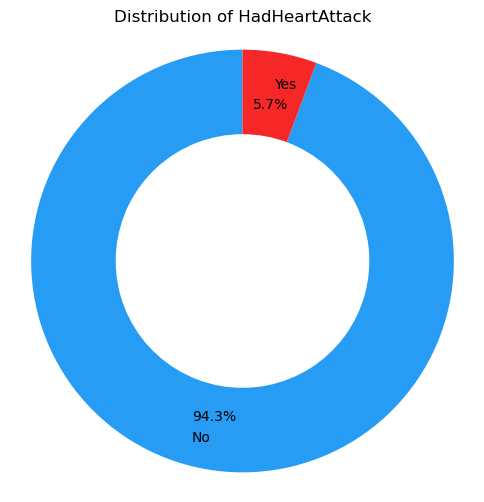

In [505]:
heart_attack_counts = data_imputed['HadHeartAttack'].value_counts(normalize=False)

plt.figure(figsize=(6, 6))

plt.pie(
    heart_attack_counts,
    labels=["No", "Yes"],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4},
    labeldistance=0.85,   # class labels
    pctdistance=0.75,      # percentages
    colors=["#279CF5", "#F52727"]
)

plt.title('Distribution of HadHeartAttack')
plt.axis('equal')
plt.show()

### States

In [390]:
# Examining the 'State' feature
state_rates = (
    data_imputed.groupby("State", observed=False)["HadHeartAttack"]
    .agg(heart_attack_rate="mean", count="count")
    .reset_index()
)
state_rates["heart_attack_rate"] *= 100

state_rates = state_rates.sort_values('heart_attack_rate', ascending=False).reset_index(drop=True)

state_rates

,State,heart_attack_rate,count
0,WV,8.978766,4945
1,AR,8.662469,5241
2,FL,7.664508,13282
3,NH,7.456010,6706
4,OK,7.219204,5707
5,KY,7.217782,4004
6,TN,7.088269,5234
7,ME,7.086168,10584
8,AZ,7.017544,10089
9,AL,6.972067,4475


In [391]:
fig = px.choropleth(
    state_rates,
    locations="State",
    locationmode="USA-states",
    color="heart_attack_rate",
    scope="usa",
    color_continuous_scale="Reds",
    labels={
        "heart_attack_rate": "Heart Attack Rate (%)"
    },
    title="Heart Attack Prevalence by State"
)

fig.show()

fig = px.choropleth(
    state_rates,
    locations="State",
    locationmode="USA-states",
    color="count",
    scope="usa",
    color_continuous_scale="Blues",
    labels={
        "count": "count"
    },
    title="Number of data entries by State"
)

fig.show()

# state_rates.sort_values('heart_attack_rate', ascending=False).reset_index(drop=True)

In [392]:
state_to_region = {
    # Northeast
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
    "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",

    # Midwest
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest", "WI": "Midwest",
    "IA": "Midwest", "KS": "Midwest", "MN": "Midwest", "MO": "Midwest", "NE": "Midwest",
    "ND": "Midwest", "SD": "Midwest",

    # South
    "DE": "South", "FL": "South", "GA": "South", "MD": "South", "NC": "South",
    "SC": "South", "VA": "South", "DC": "South", "WV": "South",
    "AL": "South", "KY": "South", "MS": "South", "TN": "South",
    "AR": "South", "LA": "South", "OK": "South", "TX": "South",

    # West
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West",
    "NM": "West", "UT": "West", "WY": "West",
    "AK": "West", "CA": "West", "HI": "West",
    "OR": "West", "WA": "West"
}

state_rates["Region"] = state_rates["State"].map(state_to_region)

state_rates
# data_imputed["Region"] = data_imputed["State"].map(state_to_region) # only if regional is useful

,State,heart_attack_rate,count,Region
0,WV,8.978766,4945,South
1,AR,8.662469,5241,South
2,FL,7.664508,13282,South
3,NH,7.456010,6706,Northeast
4,OK,7.219204,5707,South
5,KY,7.217782,4004,South
6,TN,7.088269,5234,South
7,ME,7.086168,10584,Northeast
8,AZ,7.017544,10089,West
9,AL,6.972067,4475,South


In [393]:
import plotly.express as px

fig = px.choropleth(
    state_rates,
    locations="State",          # state abbreviations (CA, TX, etc.)
    locationmode="USA-states",
    color="Region",            # color by region instead of numeric value
    scope="usa",
    hover_data={
        "heart_attack_rate": ":.2%",
        "Region": True,
    },
    title="Heart Attack Rate by State (Colored by Region)"
)

fig.update_layout(
    geo=dict(showlakes=True),
)

fig.show()

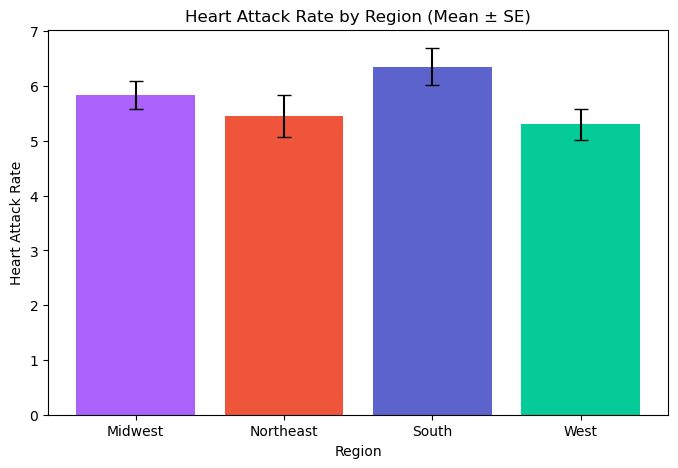

In [394]:
region_summary = (
    state_rates.groupby("Region")["heart_attack_rate"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)

region_summary["se"] = region_summary["std"] / np.sqrt(region_summary["count"])
region_summary

plt.figure(figsize=(8,5))

plt.bar(
    region_summary["Region"],
    region_summary["mean"],
    yerr=region_summary["se"],
    capsize=5,
    color=['#AA62FA', '#EF553B', '#5C63CD', '#04CB97']
)

plt.title("Heart Attack Rate by Region (Mean ± SE)")
plt.ylabel("Heart Attack Rate")
plt.xlabel("Region")

plt.show()

/var/folders/d2/b6r3bd092gd64r62_0p_5mbm0000gn/T/ipykernel_8903/2210962436.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


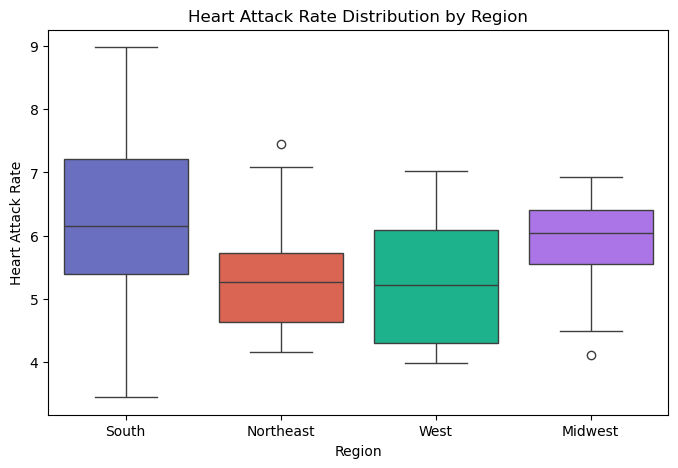

In [481]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=state_rates,
    x="Region",
    y="heart_attack_rate",
    palette=['#5C63CD', '#EF553B', '#04CB97', '#AA62FA']
)

plt.title("Heart Attack Rate Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Heart Attack Rate")

plt.show()

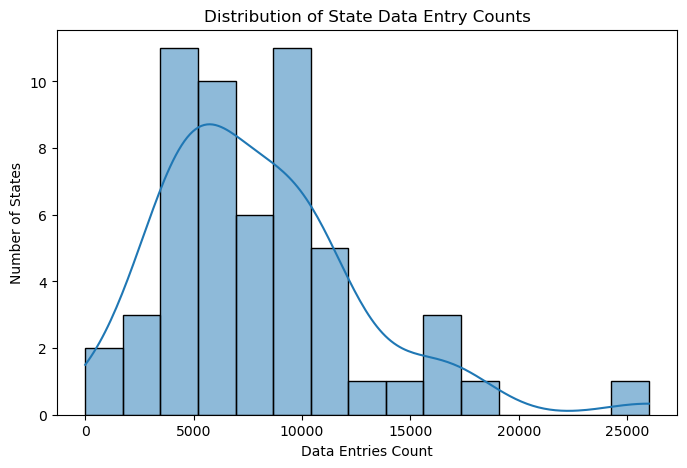

In [473]:
plt.figure(figsize=(8,5))

sns.histplot(state_rates["count"], bins=15, kde=True)

plt.title("Distribution of State Data Entry Counts")
plt.xlabel("Data Entries Count")
plt.ylabel("Number of States")

plt.show()

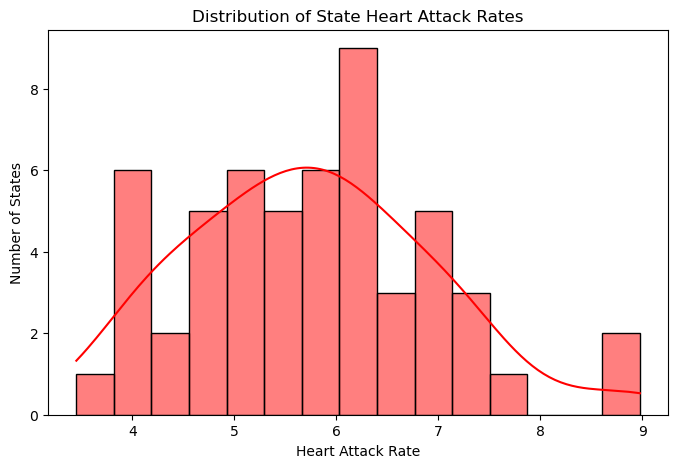

In [474]:
plt.figure(figsize=(8,5))

sns.histplot(state_rates["heart_attack_rate"], bins=15, kde=True, color='red')

plt.title("Distribution of State Heart Attack Rates")
plt.xlabel("Heart Attack Rate")
plt.ylabel("Number of States")

plt.show()

In [397]:
overall_stats = {
    "mean": state_rates["heart_attack_rate"].mean(),
    "median": state_rates["heart_attack_rate"].median(),
    "std": state_rates["heart_attack_rate"].std(),
    "IQR": state_rates["heart_attack_rate"].quantile(0.75)
         - state_rates["heart_attack_rate"].quantile(0.25)
}

overall_stats

{'mean': 5.75141476379904,
 'median': 5.721564479212209,
 'std': 1.1939521135575413,
 'IQR': 1.5211612318500132}

In [398]:
region_stats = state_rates.groupby("Region")["heart_attack_rate"].agg(
    mean="mean",
    median="median",
    std="std",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
)

region_stats

,mean,median,std,q25,q75
Region,,,,,
Midwest,5.834334,6.040182,0.875175,5.555188,6.407403
Northeast,5.455182,5.265467,1.140493,4.635882,5.729434
South,6.356709,6.155189,1.390760,5.402844,7.217782
West,5.303052,5.218505,1.010406,4.307787,6.090429


In [475]:
state_rates.head(5)

,State,heart_attack_rate,count,Region
0,WV,8.978766,4945,South
1,AR,8.662469,5241,South
2,FL,7.664508,13282,South
3,NH,7.456010,6706,Northeast
4,OK,7.219204,5707,South


In [480]:
data_imputed.describe()

,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,...,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,HighRiskLastYear,CovidPos
count,442067.000000,442067.000000,442067.000000,442067.000000,442067.000000,442067.000000,442067.000000,442067.000000,442067.000000,442067.000000,...,442067.000000,442067.000000,442067.000000,442067.000000,442067.000000,442067.000000,442067.000000,442067.000000,442067.00000,442067.000000
mean,3.436760,4.219019,4.284466,1.062152,0.761762,7.022994,4.318203,0.056797,0.059149,0.042745,...,55.309173,1.702583,82.858102,28.409431,0.579007,0.290395,0.575786,0.342595,0.03865,0.529248
std,1.049458,8.583449,8.311487,1.543244,0.426006,1.487589,8.255276,0.231454,0.235904,0.202281,...,18.259693,0.103678,20.420394,6.193497,0.493719,0.453945,0.494224,0.474578,0.19276,0.864937
min,1.000000,0.000000,0.000000,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,21.000000,0.910000,22.680000,12.020000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,3.000000,0.000000,0.000000,0.500000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,...,42.000000,1.630000,68.040000,24.410000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,3.000000,0.000000,0.000000,0.500000,1.000000,7.000000,0.000000,0.000000,0.000000,0.000000,...,57.000000,1.700000,80.740000,27.440000,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000
75%,4.000000,3.000000,4.000000,0.500000,1.000000,8.000000,3.000000,0.000000,0.000000,0.000000,...,72.000000,1.780000,91.630000,31.010000,1.000000,1.000000,1.000000,1.000000,0.00000,1.000000
max,5.000000,30.000000,30.000000,7.500000,1.000000,24.000000,32.000000,1.000000,1.000000,1.000000,...,85.000000,2.410000,292.570000,99.640000,1.000000,1.000000,1.000000,1.000000,1.00000,2.000000


Text(0.5, 1.0, 'Heart Attack Rates vs Number of Data Entries (by State)')

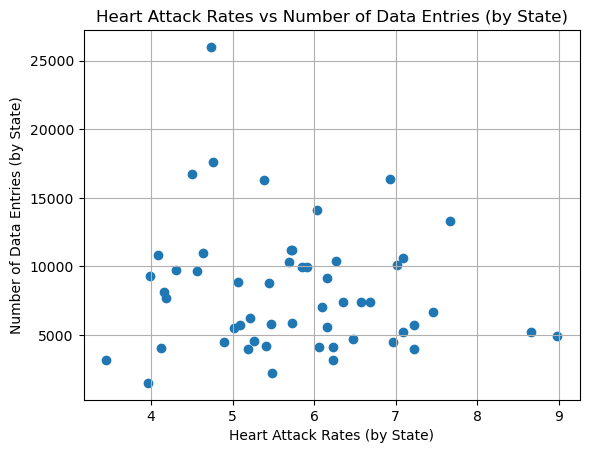

In [478]:
plt.scatter(x=state_rates["heart_attack_rate"], y=state_rates["count"])
plt.grid(visible=True, which='major')
plt.xlabel('Heart Attack Rates (by State)')
plt.ylabel('Number of Data Entries (by State)')
plt.title('Heart Attack Rates vs Number of Data Entries (by State)')

### Categorical, Continous, and Missingness Column Analysis

In [399]:
continous_cols = []
for col in data_imputed.columns:
    if data_imputed[col].unique().size > 15:
        # print(f'------- {col} --------')
        # print(f'num unique = {data_imputed[col].unique().size}')
        # print(f'values = { ", ".join(str(x) for x in data_imputed[col].unique()) }')
        continous_cols += [col]


In [ ]:
categorical_cols = ['State', 'Sex', 'GeneralHealth', 'LastCheckupTime', 'PhysicalActivities',
       'RemovedTeeth', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 
       'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap',
       'HighRiskLastYear', 'CovidPos']

continous_cols = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 
                  'HeightInMeters', 'WeightInKilograms', 'BMI']

missingness_cols = ['GeneralHealthmissing', 'PhysicalHealthDaysmissing', 
                    'MentalHealthDaysmissing', 'LastCheckupTimemissing', 
                    'PhysicalActivitiesmissing', 'SleepHoursmissing',
                    'RemovedTeethmissing', 'HadAnginamissing','HadStrokemissing', 
                    'HadAsthmamissing', 'HadSkinCancermissing', 'HadCOPDmissing', 
                    'HadDepressiveDisordermissing', 'HadKidneyDiseasemissing', 
                    'HadArthritismissing', 'HadDiabetesmissing', 
                    'DeafOrHardOfHearingmissing', 'BlindOrVisionDifficultymissing',
                    'DifficultyConcentratingmissing', 'DifficultyWalkingmissing',
                    'DifficultyDressingBathingmissing', 'DifficultyErrandsmissing',
                    'SmokerStatusmissing', 'ECigaretteUsagemissing', 'ChestScanmissing',
                    'AgeCategorymissing', 'HeightInMetersmissing','WeightInKilogramsmissing', 
                    'BMImissing', 'AlcoholDrinkersmissing', 'HIVTestingmissing', 
                    'FluVaxLast12missing', 'PneumoVaxEvermissing',
                    'HighRiskLastYearmissing', 'CovidPosmissing']


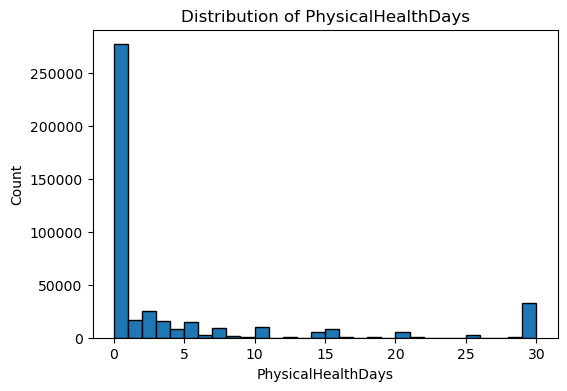

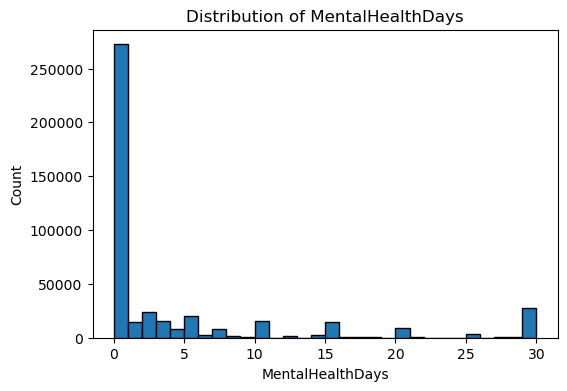

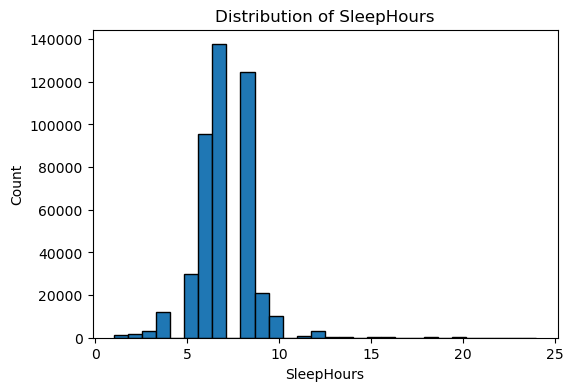

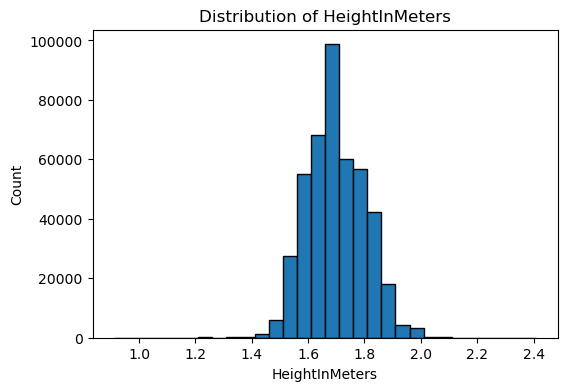

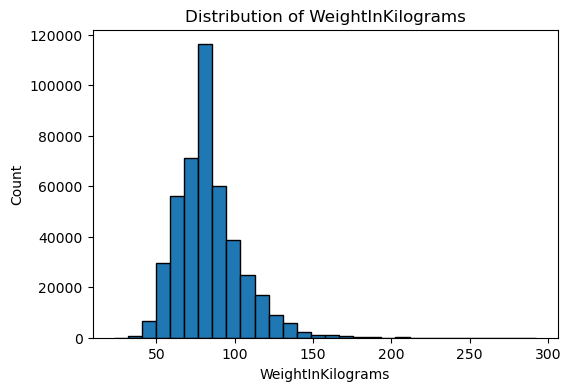

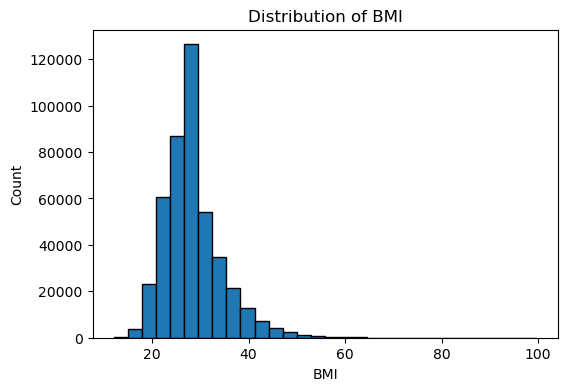

In [547]:
# Histograms for continuous variables
for col in continous_cols:
    plt.figure(figsize=(6, 4))

    plt.hist(
        data_imputed[col].dropna(),
        bins=30,
        edgecolor='black'
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

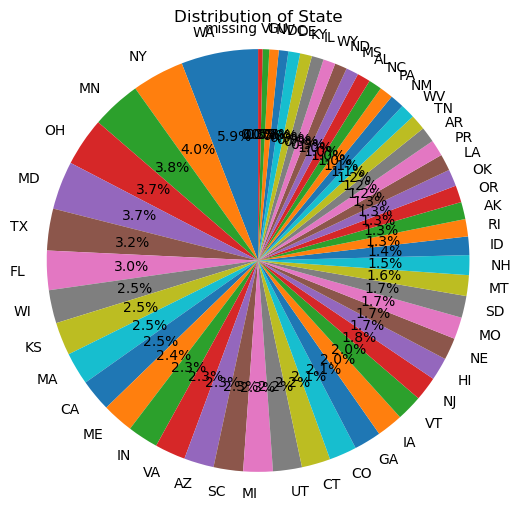

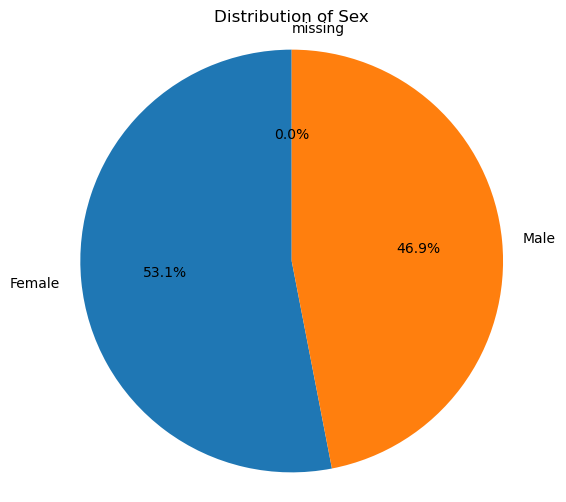

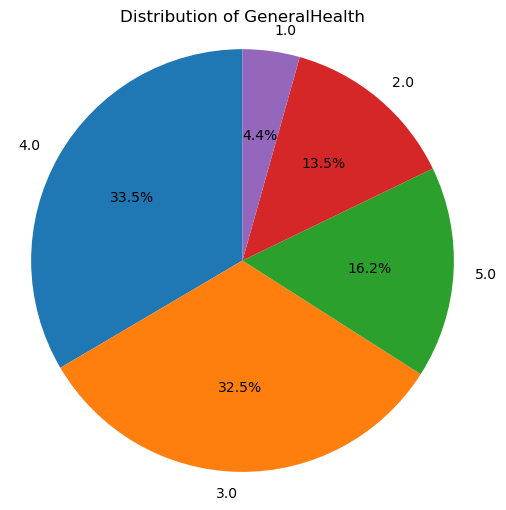

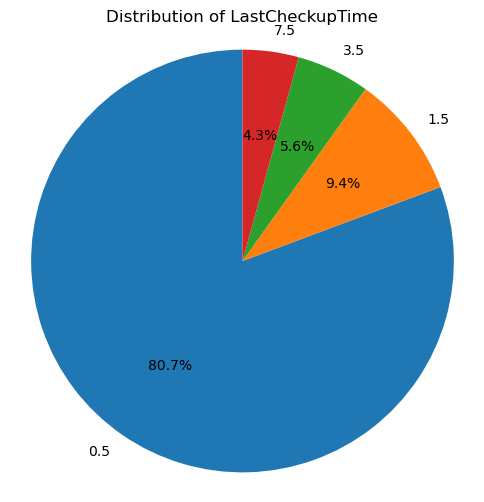

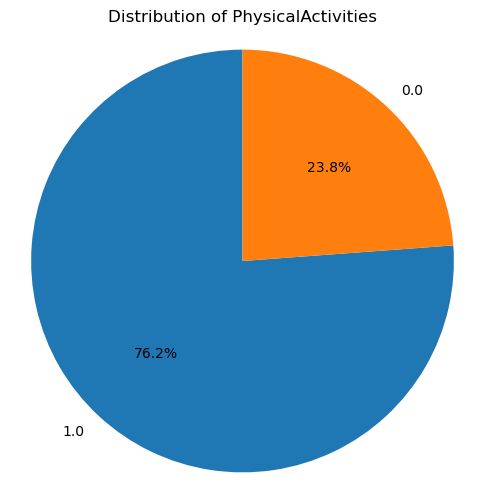

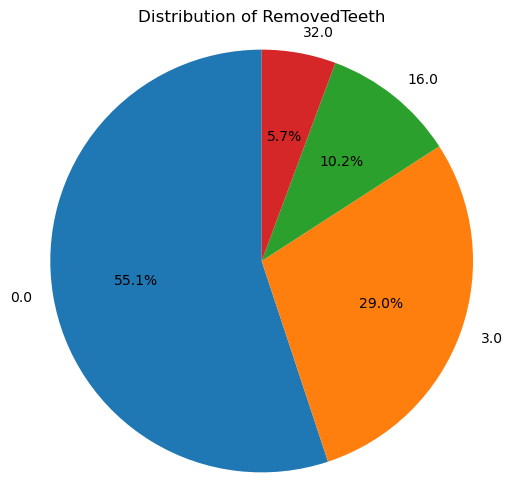

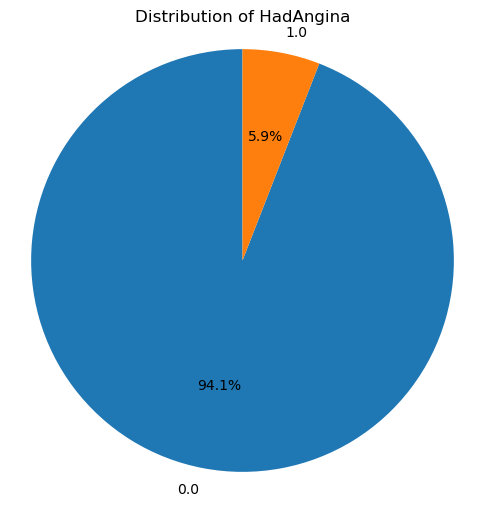

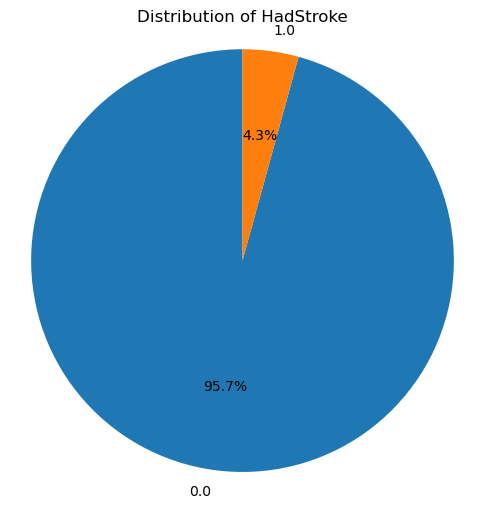

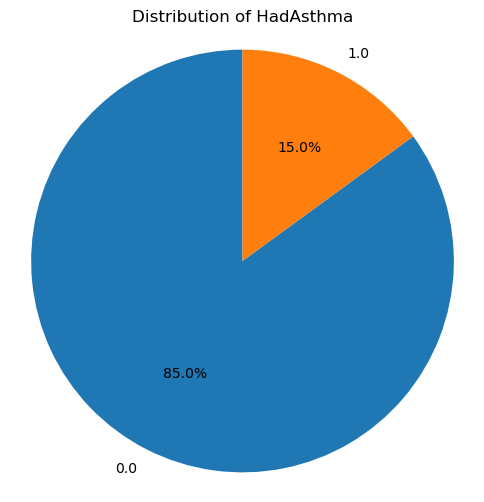

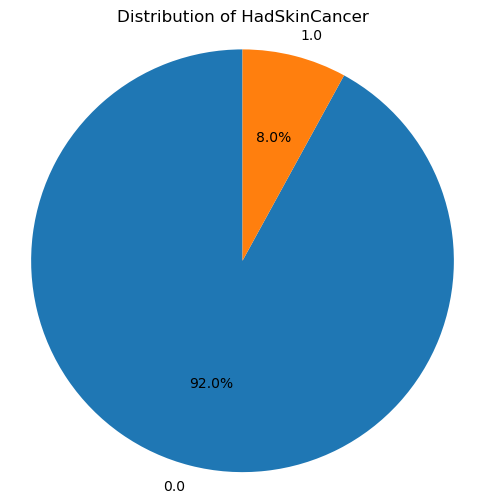

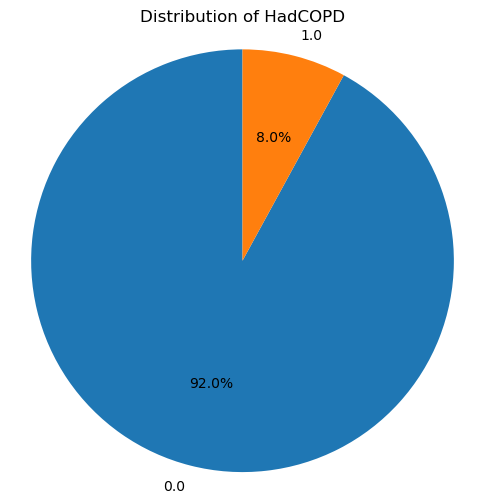

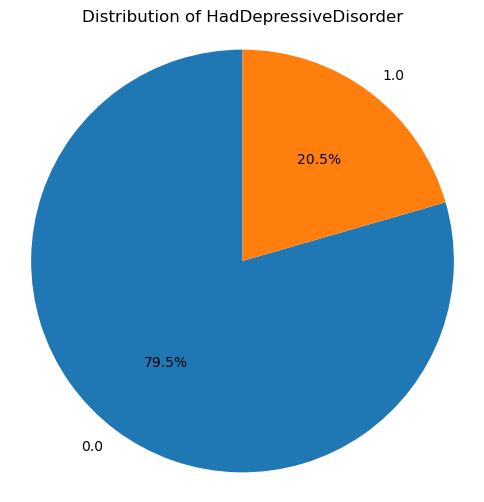

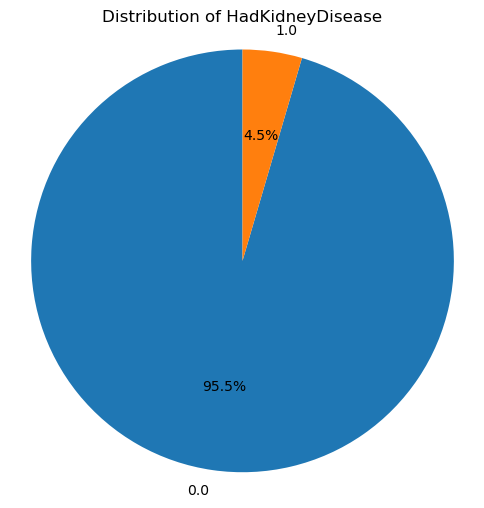

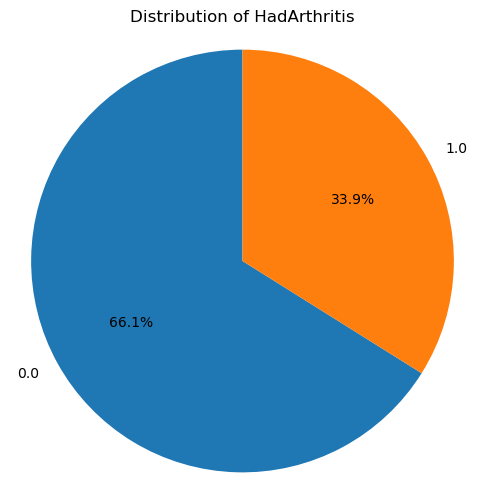

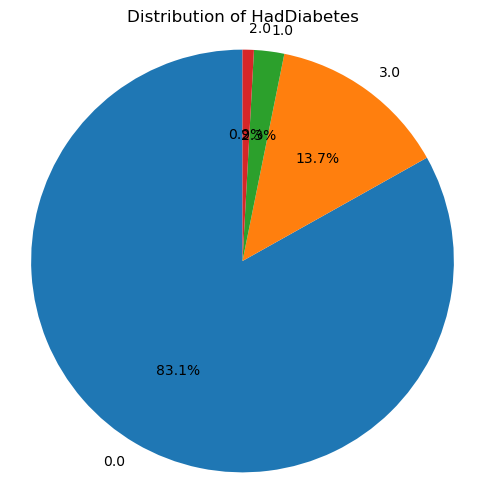

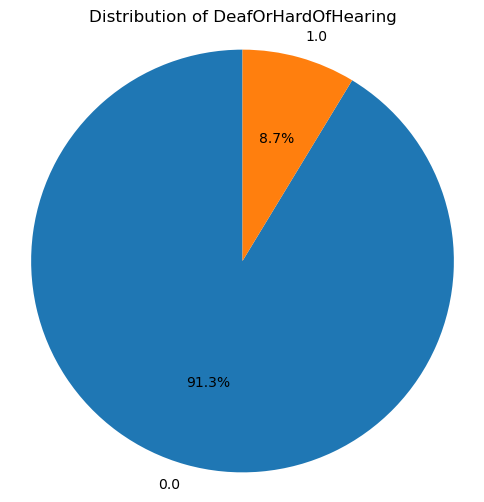

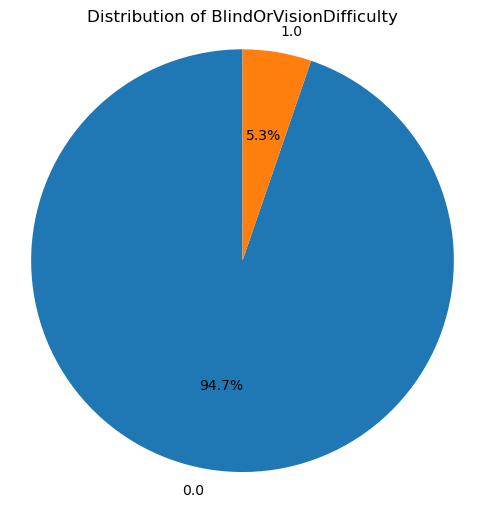

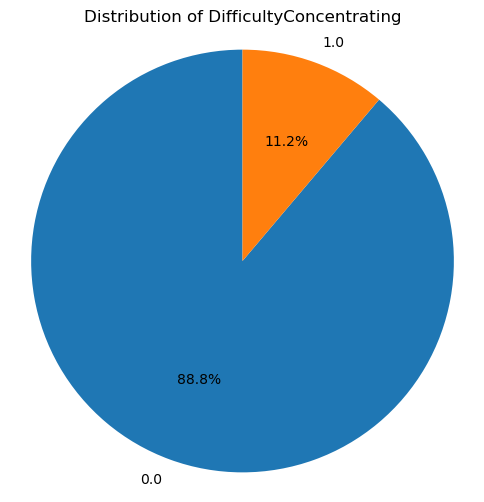

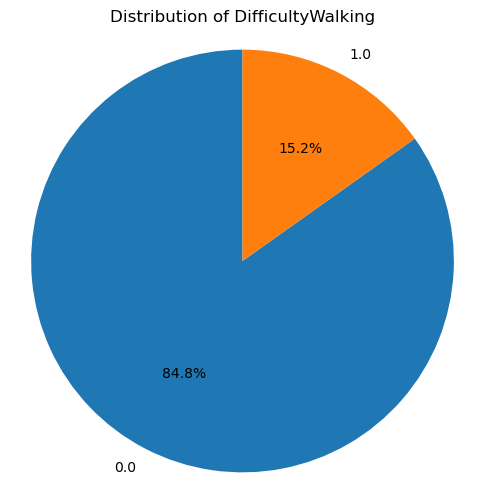

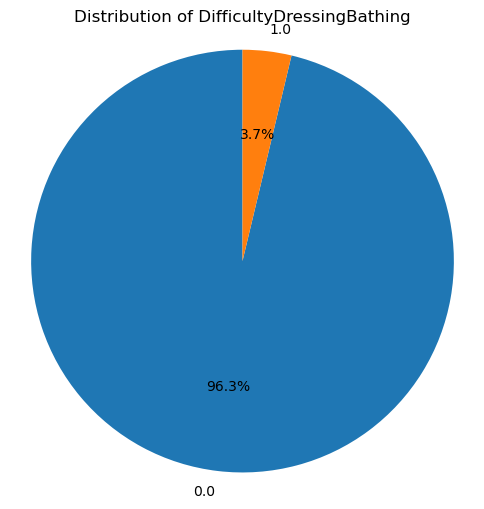

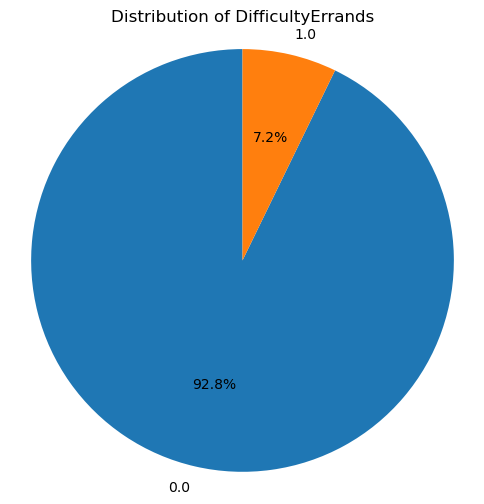

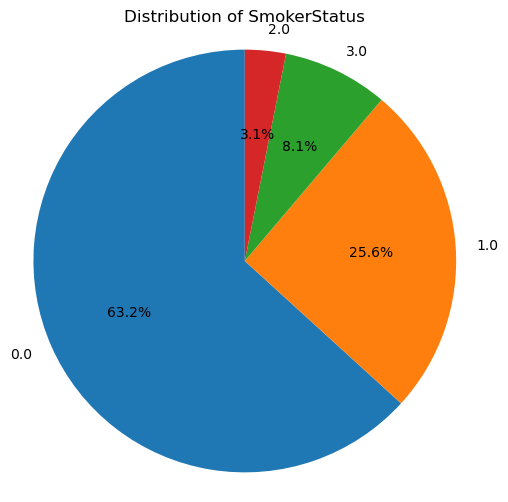

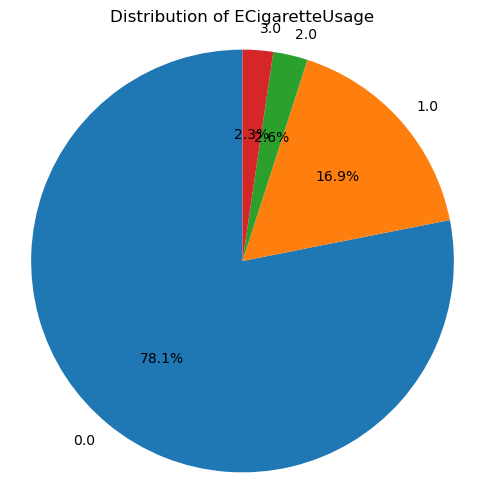

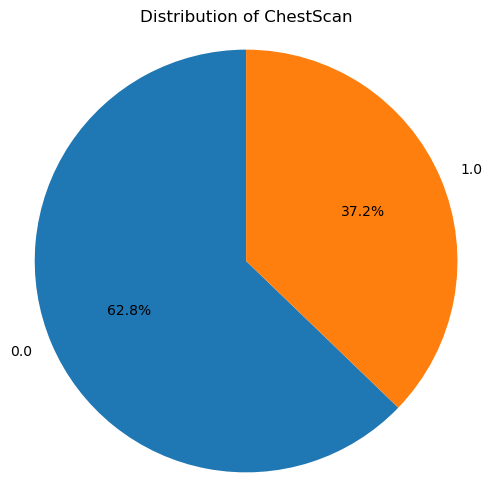

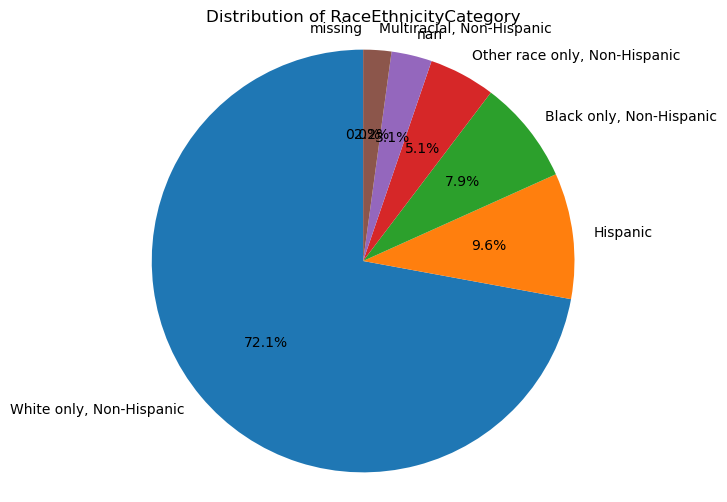

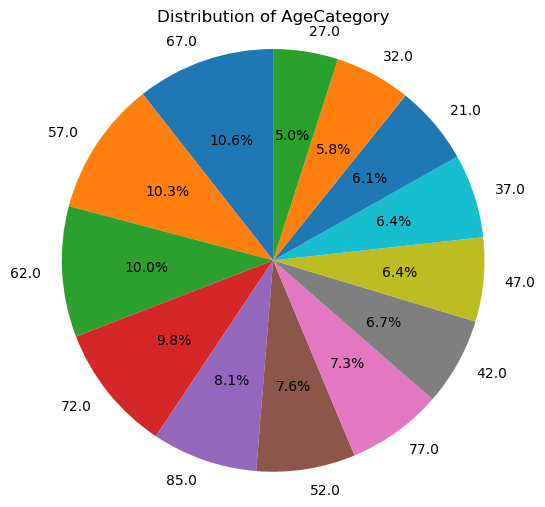

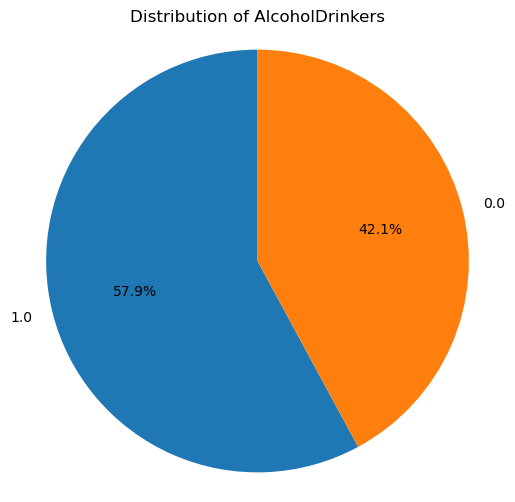

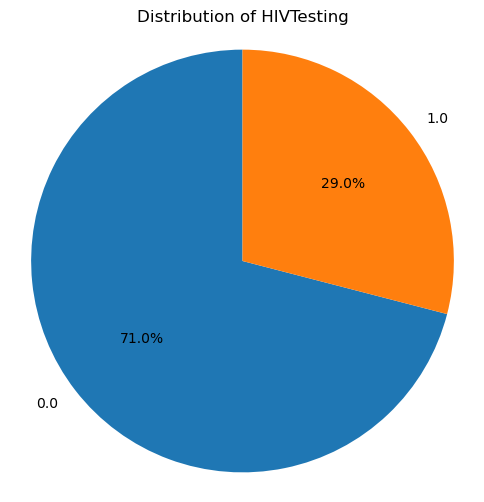

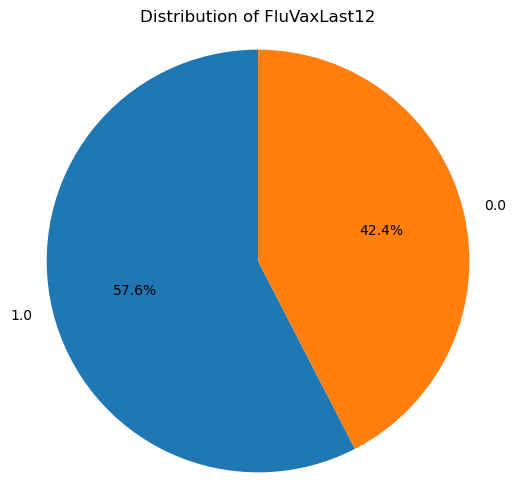

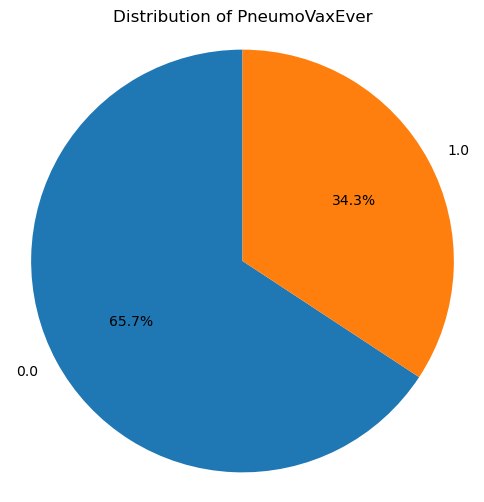

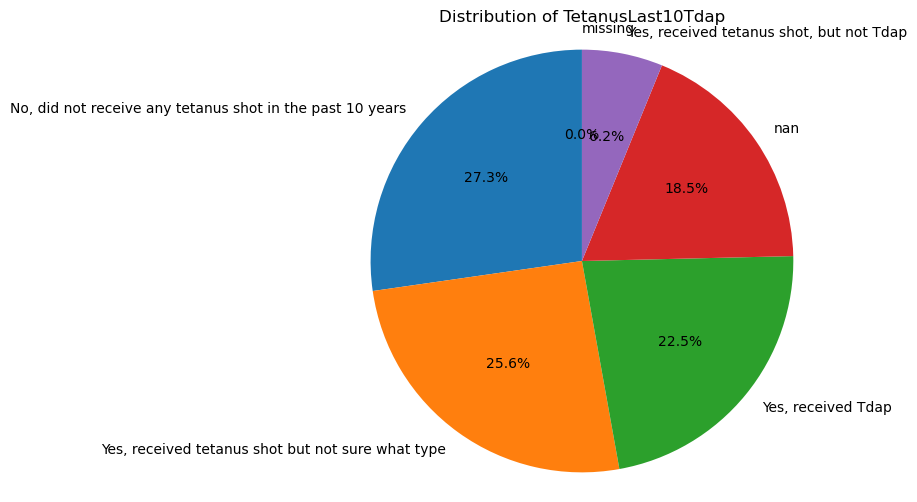

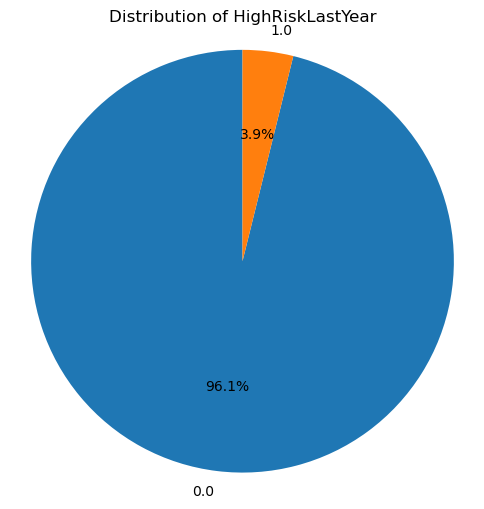

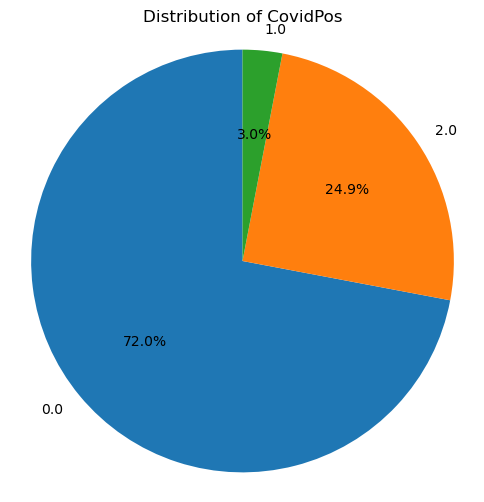

In [548]:
# Pie charts for categorical variables
for col in categorical_cols:
    counts = data_imputed[col].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )

    plt.title(f'Distribution of {col}')
    plt.axis('equal')
    plt.show()

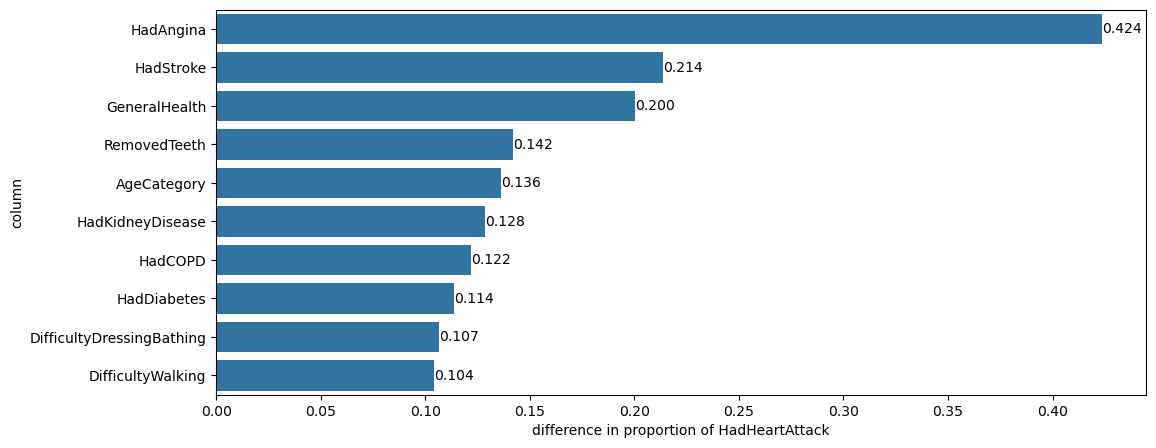

In [546]:
diff_greater_than_10 = {}
for col in categorical_cols:
    grouped_proportions = data_imputed.groupby(col, observed=False)["HadHeartAttack"]\
        .apply(lambda x: (x == 1).mean()).sort_values()
    diff = grouped_proportions.iloc[-1] - grouped_proportions.iloc[0]
    
    
    if diff > 0.10:
        # print(f"{col} difference = {diff}")
        # sns.histplot(
        #     data=data_imputed,
        #     x=col,
        #     hue="HadHeartAttack",
        #     stat="density",
        #     common_norm=False
        # )
        diff_greater_than_10[col] = diff

proportion_diff_df = (
    pd.Series(diff_greater_than_10, name="difference in proportion of HadHeartAttack")
      .rename_axis("column")
      .reset_index()
      .sort_values("difference in proportion of HadHeartAttack", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    y='column',
    x='difference in proportion of HadHeartAttack',
    data=proportion_diff_df,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')  # 3 decimal places
# plt.xticks(rotation=10, ha='right')  # tilt labels
# plt.tight_layout()                   # prevent cutoff
plt.show()

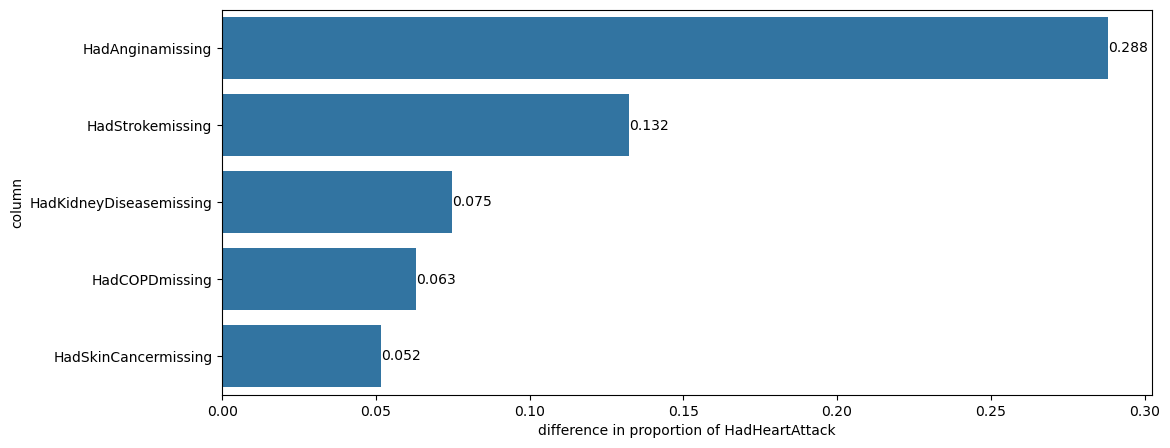

In [401]:
diff_greater_than_5 = {}

for col in missingness_cols:
    grouped_proportions = data_imputed.groupby(col, observed=False)["HadHeartAttack"]\
        .apply(lambda x: (x == 1).mean()).sort_values()
    diff = grouped_proportions.iloc[-1] - grouped_proportions.iloc[0]
    
    
    if diff > 0.05:
        # print(f"{col} difference = {diff}")
        # sns.histplot(
        #     data=data_imputed,
        #     x=col,
        #     hue="HadHeartAttack",
        #     stat="density",
        #     common_norm=False
        # )
        diff_greater_than_5[col] = diff

missingness_proportion_diff_df = (
    pd.Series(diff_greater_than_5, name="difference in proportion of HadHeartAttack")
      .rename_axis("column")
      .reset_index()
      .sort_values("difference in proportion of HadHeartAttack", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    y='column',
    x='difference in proportion of HadHeartAttack',
    data=missingness_proportion_diff_df,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')  # 3 decimal places
# plt.xticks(rotation=30, ha='right')  # tilt labels
# plt.tight_layout()                   # prevent cutoff
plt.show()

In [402]:
def plot_hist_with_stats(df, value_col, hue_col, bins=25):
    plt.figure(figsize=(10, 6))

    # Histogram
    sns.histplot(
        data=df,
        x=value_col,
        hue=hue_col,
        bins=bins,
        stat="density",
        common_norm=False,
        alpha=0.4,
        palette=["red", "blue"]
    )

    # Mean/Median lines
    for group, color in zip(sorted(df[hue_col].dropna().unique()), ['red', 'blue']):
        vals = df.loc[df[hue_col] == group, value_col].dropna()
        if group == 1:
            ha = "had heart attack"
        else:
            ha="no heart attack"
        mean = vals.mean()
        median = vals.median()

        plt.axvline(
            mean,
            linestyle="--",
            linewidth=2,
            label=f"{ha} Mean",
            color = color
        )

        # plt.axvline(
        #     median,
        #     linestyle=":",
        #     linewidth=2,
        #     label=f"{group} Median",
        #     color = color
        # )

    plt.title(f"{value_col} by {hue_col}")
    plt.legend()
    plt.show()

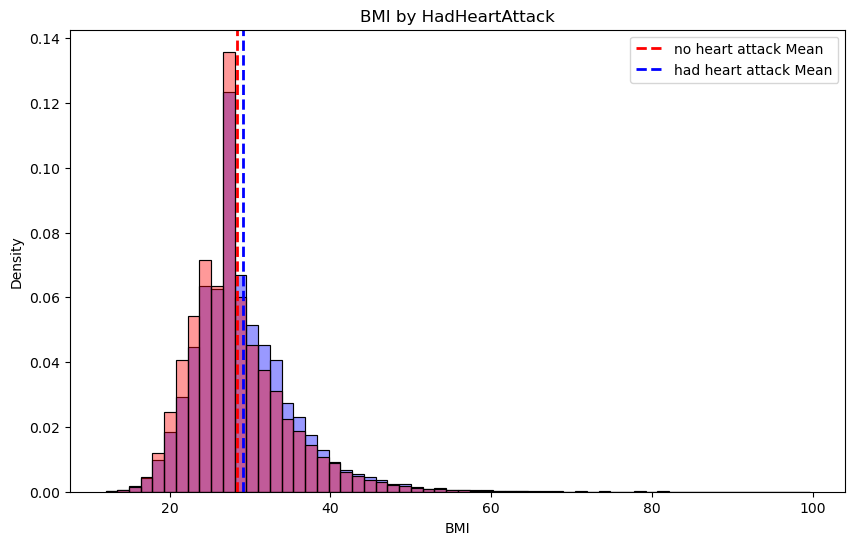

In [403]:
plot_hist_with_stats(
    data_imputed,
    value_col="BMI",
    hue_col="HadHeartAttack",
    bins=60
)

In [404]:
pd.qcut(data_imputed["BMI"], q=10)

0          (26.63, 27.44]
1          (25.11, 26.63]
2          (25.11, 26.63]
3          (21.79, 23.71]
4         (12.019, 21.79]
               ...       
445127     (25.11, 26.63]
445128     (28.19, 29.95]
445129    (12.019, 21.79]
445130     (32.28, 36.26]
445131     (21.79, 23.71]
Name: BMI, Length: 442067, dtype: category
Categories (10, interval[float64, right]): [(12.019, 21.79] < (21.79, 23.71] < (23.71, 25.11] < (25.11, 26.63] ... (28.19, 29.95] < (29.95, 32.28] < (32.28, 36.26] < (36.26, 99.64]]

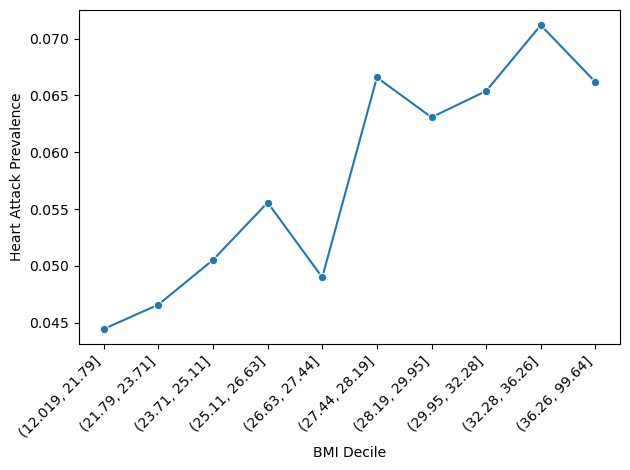

In [405]:
df = data_imputed.copy()

df["BMI_bin"] = pd.qcut(df["BMI"], q=10)

prevalence = (
    df.groupby("BMI_bin", observed=False)["HadHeartAttack"]
      .mean()
      .reset_index()
)

prevalence["BMI_bin"] = prevalence["BMI_bin"].astype(str)

sns.lineplot(
    data=prevalence,
    x="BMI_bin",
    y="HadHeartAttack",
    marker="o"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Heart Attack Prevalence")
plt.xlabel("BMI Decile")
plt.tight_layout()
plt.show()

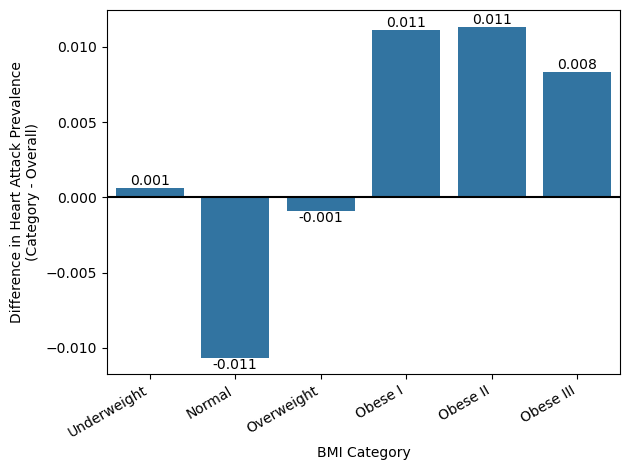

In [406]:
df = data_imputed.copy()
data_prop_ha = data_imputed["HadHeartAttack"].mean()

df["BMI_category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 35, 40, np.inf],
    labels=[
        "Underweight", "Normal", "Overweight",
        "Obese I", "Obese II", "Obese III"
    ]
)

prevalence = (
    df.groupby("BMI_category", observed=False)["HadHeartAttack"]
      .mean()
      .reset_index()
      .rename(columns={"HadHeartAttack": "category_rate"})
)

overall = data_imputed["HadHeartAttack"].mean()

prevalence["diff_vs_overall"] = prevalence["category_rate"] - overall
prevalence["pct_change_vs_overall"] = (
    (prevalence["category_rate"] - overall) / overall
) * 100

ax = sns.barplot(
    data=prevalence,
    x="BMI_category",
    y="diff_vs_overall",
)

ax.axhline(0, color="black")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=30, ha="right")

plt.ylabel("Difference in Heart Attack Prevalence\n(Category - Overall)")
plt.xlabel("BMI Category")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

# Models
We will be evaluating our models with F1 scores to account for the unequal sizes of the two target categories

In [519]:
# imports for modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, f1_score, average_precision_score,
                             precision_recall_curve)



# models
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# hyperparameter tuning
from sklearn.model_selection import ParameterSampler

## Preproc, test train split

In [412]:
X = data_imputed.drop(columns=["HadHeartAttack"])
y = data_imputed["HadHeartAttack"]

In [ ]:
# OHE categorical columns, StandardScaler numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), 
            continous_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), 
            ['State', 'Region', 'Sex', 'RaceEthnicityCategory', 'TetanusLast10Tdap']),
    ], 
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
])

X_OHE = pipeline.fit_transform(X)

feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

X_OHE = pd.DataFrame(
    X_OHE,
    columns=feature_names,
    index=X.index
)
X_OHE.head(5)

,num__PhysicalHealthDays,num__MentalHealthDays,num__SleepHours,num__HeightInMeters,num__WeightInKilograms,num__BMI,cat__State_AL,cat__State_AR,cat__State_AZ,cat__State_CA,...,remainder__AgeCategorymissing,remainder__HeightInMetersmissing,remainder__WeightInKilogramsmissing,remainder__BMImissing,remainder__AlcoholDrinkersmissing,remainder__HIVTestingmissing,remainder__FluVaxLast12missing,remainder__PneumoVaxEvermissing,remainder__HighRiskLastYearmissing,remainder__CovidPosmissing
0,-0.49153,-0.515488,0.656772,-0.024913,-0.103725,-0.156524,1.0,0.0,0.0,0.0,...,False,True,True,True,False,False,False,False,False,False
1,-0.49153,-0.515488,-0.687687,-0.98944,-0.725653,-0.296994,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,-0.258523,-0.154541,-1.359916,-1.278798,-0.94798,-0.451996,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,-0.49153,-0.515488,-0.015457,-0.507176,-0.94798,-0.824968,1.0,0.0,0.0,0.0,...,True,False,False,False,False,False,False,False,False,False
4,-0.258523,-0.515488,1.329001,-1.278798,-1.414181,-1.072001,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [419]:
# StandardScaler numerical columns, leave categories as is for LightsumGBM and CapBoost
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continous_cols),
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
])

X_standard_scaler = pipeline.fit_transform(X)

feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

X_standard_scaler = pd.DataFrame(
    X_standard_scaler,
    columns=feature_names,
    index=X.index
)

X_standard_scaler.head(5)

,num__PhysicalHealthDays,num__MentalHealthDays,num__SleepHours,num__HeightInMeters,num__WeightInKilograms,num__BMI,remainder__State,remainder__Sex,remainder__GeneralHealth,remainder__LastCheckupTime,...,remainder__AgeCategorymissing,remainder__HeightInMetersmissing,remainder__WeightInKilogramsmissing,remainder__BMImissing,remainder__AlcoholDrinkersmissing,remainder__HIVTestingmissing,remainder__FluVaxLast12missing,remainder__PneumoVaxEvermissing,remainder__HighRiskLastYearmissing,remainder__CovidPosmissing
0,-0.49153,-0.515488,0.656772,-0.024913,-0.103725,-0.156524,AL,Female,4.0,0.5,...,False,True,True,True,False,False,False,False,False,False
1,-0.49153,-0.515488,-0.687687,-0.98944,-0.725653,-0.296994,AL,Female,5.0,0.5,...,False,False,False,False,False,False,False,False,False,False
2,-0.258523,-0.154541,-1.359916,-1.278798,-0.94798,-0.451996,AL,Female,4.0,0.5,...,False,False,False,False,False,False,False,False,False,False
3,-0.49153,-0.515488,-0.015457,-0.507176,-0.94798,-0.824968,AL,Female,5.0,0.5,...,True,False,False,False,False,False,False,False,False,False
4,-0.258523,-0.515488,1.329001,-1.278798,-1.414181,-1.072001,AL,Female,2.0,0.5,...,False,False,False,False,False,False,False,False,False,False


## Different Models
We will be experimenting with KNN, Logistical Regression, Random Forest, CapBoost, ensemble model, XGBoost / LightGBM. 

We will be using logistical regression as the baseline model

In [535]:
def best_f1_thresold(y_test, y_test_prob):
    # Compute precision, recall, thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)

    # Compute F1 for each threshold
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
        precision[:-1] + recall[:-1]
    )

    # Best threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    return best_f1, best_threshold

### Logistical Regression

In [532]:
def train_fit_test_log(model, X, y=y, val=False):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,      # 80/20 split
        random_state=42,    # reproducibility
        stratify=y          # preserve class proportions
    )

    fitted_model = model.fit(X_train, y_train)

    # Evaluate on test set
    y_test_pred = fitted_model.predict(X_test)
    y_test_prob = fitted_model.predict_proba(X_test)[:, 1]
    c_mat = confusion_matrix(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_prob)
    report = classification_report(y_test, y_test_pred)
    pr_auc = average_precision_score(y_test, y_test_prob)

    best_threshold, best_f1 = best_f1_thresold(y_test, y_test_prob)
    
    # print output
    print("=== [Block 1] Test Set ===")
    print("classification report")
    print(report)
    print(f"Confusion Matrix:\n{c_mat}")
    print(f"ROC-AUC Score: {roc_auc}")
    print(f"Best F1 Score: {best_f1}, threshold = {best_threshold}")
    print(f"PR-AUC Score: {pr_auc}")    
    
    return fitted_model, c_mat, roc_auc, report



#### numerical, binary, and ordinal categorical

In [533]:
train_fit_test_log(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X.select_dtypes('float64')
)

=== [Block 1] Test Set ===
classification report
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90     83392
         1.0       0.21      0.75      0.33      5022

    accuracy                           0.83     88414
   macro avg       0.60      0.79      0.62     88414
weighted avg       0.94      0.83      0.87     88414

Confusion Matrix:
[[69572 13820]
 [ 1256  3766]]
ROC-AUC Score: 0.879331990899673
Best F1 Score: 0.7922529624423371, threshold = 0.4552482391341694
PR-AUC Score: 0.3900990578939162


/Users/gracechen/anaconda3/envs/stats/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 array([[69572, 13820],
        [ 1256,  3766]]),
 0.879331990899673,
 '              precision    recall  f1-score   support\n\n         0.0       0.98      0.83      0.90     83392\n         1.0       0.21      0.75      0.33      5022\n\n    accuracy                           0.83     88414\n   macro avg       0.60      0.79      0.62     88414\nweighted avg       0.94      0.83      0.87     88414\n')

#### with ALL columns transformed numerically (OHE, mapping)

In [534]:
train_fit_test_log(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_OHE
)

=== [Block 1] Test Set ===
classification report
              precision    recall  f1-score   support

         0.0       0.98      0.84      0.91     83392
         1.0       0.22      0.76      0.35      5022

    accuracy                           0.84     88414
   macro avg       0.60      0.80      0.63     88414
weighted avg       0.94      0.84      0.87     88414

Confusion Matrix:
[[70131 13261]
 [ 1184  3838]]
ROC-AUC Score: 0.8883828031183131
Best F1 Score: 0.8445835696931946, threshold = 0.47518187678423424
PR-AUC Score: 0.41457475554491285


(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 array([[70131, 13261],
        [ 1184,  3838]]),
 0.8883828031183131,
 '              precision    recall  f1-score   support\n\n         0.0       0.98      0.84      0.91     83392\n         1.0       0.22      0.76      0.35      5022\n\n    accuracy                           0.84     88414\n   macro avg       0.60      0.80      0.63     88414\nweighted avg       0.94      0.84      0.87     88414\n')

### CapBoost

In [ ]:
def train_fit_test_CB(model, X, y=y, cat_features=None): 
    if cat_features is None: 
        cat_features = (X.select_dtypes('category').columns.values).tolist() 
    X_train, X_test, y_train, y_test = train_test_split( 
        X, y, 
        test_size=0.2, # 80/20 split 
        random_state=42, # reproducibility 
        stratify=y # preserve class proportions 
    ) # IMPORTANT: create validation split for early stopping 
    X_train2, X_val, y_train2, y_val = train_test_split( 
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train 
    ) 
    
    model.fit(
        X_train2, y_train2, 
        cat_features=cat_features, 
        eval_set=(X_val, y_val), 
        use_best_model=True
    ) 
    y_test_pred = model.predict(X_test) # Handle models whose predict returns probabilities differently 
    if hasattr(model, "predict_proba"): 
        y_test_prob = model.predict_proba(X_test)[:, 1] 
    else: 
        y_test_prob = model.predict(X_test) 
    
    c_mat = confusion_matrix(y_test, y_test_pred) 
    report = classification_report(y_test, y_test_pred) 
    roc_auc = roc_auc_score(y_test, y_test_prob) 
    f1, threshold = best_f1_thresold(y_test, y_test_pred)
    pr_auc = average_precision_score(y_test, y_test_prob)

    print("=== Test Set ===") 
    print(report) 
    print(f"Confusion Matrix:\n{c_mat}") 
    print(f"ROC-AUC Score: {roc_auc}") 
    print(f"F1 Score: {f1}, threshold = {threshold}")
    print(f"PR-AUC Score: {pr_auc}")  
    return model, c_mat, roc_auc, report

In [512]:
train_fit_test_CB(CatBoostClassifier(
        auto_class_weights="Balanced",
        iterations=5000,   # set high upper bound
        depth=6,
        learning_rate=0.05,
        early_stopping_rounds=50,
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    ),
    X, 
    cat_features= ['State', 'Sex', 'RaceEthnicityCategory', 'TetanusLast10Tdap', 'Region']
)

=== Test Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90     83392
         1.0       0.21      0.78      0.34      5022

    accuracy                           0.82     88414
   macro avg       0.60      0.80      0.62     88414
weighted avg       0.94      0.82      0.87     88414

Confusion Matrix:
[[69002 14390]
 [ 1110  3912]]
ROC-AUC Score: 0.8905018537200706
F1 Score: 0.33544846510032583
PR-AUC Score: 0.43056245551752637


(CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=5000, learning_rate=0.05, random_seed=42, verbose=False),
 array([[69002, 14390],
        [ 1110,  3912]]),
 0.8905018537200706,
 '              precision    recall  f1-score   support\n\n         0.0       0.98      0.83      0.90     83392\n         1.0       0.21      0.78      0.34      5022\n\n    accuracy                           0.82     88414\n   macro avg       0.60      0.80      0.62     88414\nweighted avg       0.94      0.82      0.87     88414\n')

#### hyperameter tuning
not worth it, score improves less that 0.0001 

In [528]:
# hyper parameter tuning
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

def train_fit_test_CB_fixed(model, X_train2, y_train2, X_val, 
                            y_val, X_test, y_test, cat_features):

    model.fit(
        X_train2, y_train2,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Compute precision, recall, thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)

    # Compute F1 for each threshold
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
        precision[:-1] + recall[:-1]
    )

    # Best threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    c_mat = confusion_matrix(y_test, y_test_pred) 
    report = classification_report(y_test, y_test_pred) 

    roc_auc = roc_auc_score(y_test, y_test_prob)
    pr_auc = average_precision_score(y_test, y_test_prob)

    return roc_auc, best_f1, pr_auc, best_threshold, c_mat, report

In [521]:
param_dist = {
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": np.linspace(0.03, 0.1, 5),
    "l2_leaf_reg": [1, 3, 5, 7, 9]
}

samples = list(ParameterSampler(param_dist, n_iter=15, random_state=42))
samples

[{'learning_rate': 0.0825, 'l2_leaf_reg': 7, 'depth': 4},
 {'learning_rate': 0.065, 'l2_leaf_reg': 7, 'depth': 5},
 {'learning_rate': 0.0475, 'l2_leaf_reg': 5, 'depth': 5},
 {'learning_rate': 0.0475, 'l2_leaf_reg': 1, 'depth': 7},
 {'learning_rate': 0.0825, 'l2_leaf_reg': 1, 'depth': 6},
 {'learning_rate': 0.0475, 'l2_leaf_reg': 7, 'depth': 7},
 {'learning_rate': 0.0475, 'l2_leaf_reg': 3, 'depth': 6},
 {'learning_rate': 0.0825, 'l2_leaf_reg': 9, 'depth': 8},
 {'learning_rate': 0.0825, 'l2_leaf_reg': 7, 'depth': 7},
 {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'depth': 4},
 {'learning_rate': 0.065, 'l2_leaf_reg': 1, 'depth': 5},
 {'learning_rate': 0.0475, 'l2_leaf_reg': 7, 'depth': 8},
 {'learning_rate': 0.1, 'l2_leaf_reg': 7, 'depth': 5},
 {'learning_rate': 0.0475, 'l2_leaf_reg': 9, 'depth': 7},
 {'learning_rate': 0.1, 'l2_leaf_reg': 7, 'depth': 4}]

In [529]:
# loop thru to find best parameters in samples --> not worth it, score doesn't improve
best_score = 0
best_params = None
scores = []

for param in samples:
    d = param["depth"]
    l = param["learning_rate"]
    reg = param["l2_leaf_reg"]

    model = CatBoostClassifier(
        auto_class_weights="Balanced",
        iterations=5000,
        depth=d,
        learning_rate=l,
        l2_leaf_reg=reg,
        early_stopping_rounds=50,
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )

    roc_auc, f1, pr_auc, threshold, c_mat, report = train_fit_test_CB_fixed(
        model,
        X_train2, y_train2,
        X_val, y_val,
        X_test, y_test,
        cat_features=['State','Sex','RaceEthnicityCategory','TetanusLast10Tdap','Region']
    )

    score = sum([roc_auc, f1, pr_auc])

    if score > best_score:
        print("*********** NEW BEST SCORE ***********")
        best_score = score
        best_params = (d, l, reg)
    else:
        print("=====================================")
    print(f"depth = {d}, learning rate = {l}, l2_leaf_reg = {reg}, threshold = {threshold}")
    print(f"ROC-AUC Score: {roc_auc}")
    print(f"F1 Score: {f1}")
    print(f"PR-AUC Score: {pr_auc}")  
print(best_score, best_params)

*********** NEW BEST SCORE ***********
depth = 4, learning rate = 0.0825, l2_leaf_reg = 7, threshold = 0.8523787335813737
ROC-AUC Score: 0.8902684099402384
F1 Score: 0.48578957274609447
PR-AUC Score: 0.42830431279640463
*********** NEW BEST SCORE ***********
depth = 5, learning rate = 0.065, l2_leaf_reg = 7, threshold = 0.8425094951594352
ROC-AUC Score: 0.8904907289354316
F1 Score: 0.48564017046507324
PR-AUC Score: 0.4289642388340824
*********** NEW BEST SCORE ***********
depth = 5, learning rate = 0.0475, l2_leaf_reg = 5, threshold = 0.8540327985700833
ROC-AUC Score: 0.8904373925296616
F1 Score: 0.48732021196063585
PR-AUC Score: 0.42895920865458975
depth = 7, learning rate = 0.0475, l2_leaf_reg = 1, threshold = 0.8173262899107934
ROC-AUC Score: 0.890100621253438
F1 Score: 0.48563968668407315
PR-AUC Score: 0.4297847030303302
depth = 6, learning rate = 0.0825, l2_leaf_reg = 1, threshold = 0.8358115720284338
ROC-AUC Score: 0.8901376155201075
F1 Score: 0.4868941414513014
PR-AUC Score: 0.4

### Native Bayes

In [539]:

def train_fit_test_NB(model, X, y=y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_test_prob = y_test_pred
    
    c_mat = confusion_matrix(y_test, y_test_pred) 
    report = classification_report(y_test, y_test_pred) 
    roc_auc = roc_auc_score(y_test, y_test_prob) 
    best_f1, threshold = best_f1_thresold(y_test, y_test_pred)
    pr_auc = average_precision_score(y_test, y_test_prob)

    print("=== Test Set ===") 
    print(report) 
    print(f"Confusion Matrix:\n{c_mat}") 
    print(f"ROC-AUC Score: {roc_auc}") 
    print(f"F1 Score: {best_f1}, threshold = {threshold}")
    print(f"PR-AUC Score: {pr_auc}")  

    return roc_auc, c_mat, report

In [540]:
train_fit_test_NB(
    GaussianNB(),
    X_OHE.apply(pd.to_numeric)
)

=== Test Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90     83392
         1.0       0.19      0.65      0.29      5022

    accuracy                           0.82     88414
   macro avg       0.58      0.74      0.59     88414
weighted avg       0.93      0.82      0.86     88414

Confusion Matrix:
[[69161 14231]
 [ 1740  3282]]
ROC-AUC Score: 0.8121984548206617
F1 Score: 0.2912802307521633, threshold = 1.0
PR-AUC Score: 0.20154867134528687


(0.8121984548206617,
 array([[69161, 14231],
        [ 1740,  3282]]),
 '              precision    recall  f1-score   support\n\n         0.0       0.98      0.83      0.90     83392\n         1.0       0.19      0.65      0.29      5022\n\n    accuracy                           0.82     88414\n   macro avg       0.58      0.74      0.59     88414\nweighted avg       0.93      0.82      0.86     88414\n')

## Hyper Parameter Tuning